Design deeper CNN (4-6 layers)
Add dropout, batch normalization
Hyperparameter tuning
Train improved model
Compare to baseline
Get better accuracy (~85-90%)

import libs load preprocessed data (same as notebook 3)

In [1]:
#imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from datetime import datetime
from tensorflow.keras import models, layers

# tensorflow import
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#for metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#random seed for reporoductivity (default 42)
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)


In [2]:
#rerun preprocessing (copy from Notebook 2)
from sklearn.model_selection import train_test_split

#load raw data
train_data = pd.read_csv('../data/sign_mnist_train.csv')
test_data = pd.read_csv('../data/sign_mnist_test.csv')

#separate features and labels
X_train_full = train_data.drop('label', axis=1).values
y_train_full = train_data['label'].values

#preprocess
X_train_full = X_train_full / 255.0  # Normalize
X_train_full = X_train_full.reshape(-1, 28, 28, 1)  # Reshape

# one hot encode
y_train_full_encoded = keras.utils.to_categorical(y_train_full, 25)

# train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print(f"   Training set: {X_train.shape[0]:,} images")
print(f"   Validation set: {X_val.shape[0]:,} images")
print(f"   Image shape: {X_train.shape[1:]}")
print(f"   Number of classes: {y_train.shape[1]}")

   Training set: 21,964 images
   Validation set: 5,491 images
   Image shape: (28, 28, 1)
   Number of classes: 25


load baseline performance for comparison 

In [ ]:
print("\nBaseline model performance (for comparison):")
try:
    with open('../results/metrics/baseline_metrics.txt', 'r') as f:
        for line in f:
            if 'Accuracy:' in line:
                baseline_acc = float(line.split(':')[1].strip().split()[0])
                print(f"   Baseline Validation Accuracy: {baseline_acc*100:.2f}%")
                break
except:
    baseline_acc = 0.75
    print(f"   Baseline Accuracy: ~{baseline_acc*100:.1f}% (estimated)")

# Handle the 100% case
if baseline_acc >= 1.0:
    print(f"\nNote: Baseline already achieved 100% on validation set.")
    print(f"Goal: Match baseline performance with a more robust architecture")
    print(f"(deeper layers, BatchNorm, Dropout = better generalisation in real-world use)")
else:
    print(f"\nTarget: Beat {baseline_acc*100:.2f}% accuracy")


Baseline model performance (for comparison):
   Baseline Validation Accuracy: 100.00%

Note: Baseline already achieved 100% on validation set.
Goal: Match baseline performance with a more robust architecture
      (deeper layers, BatchNorm, Dropout = better generalisation in real-world use)


### results 

baseline model performance (for comparison):
   - Accuracy: 1.0000 (100.00%)

Target: Beat 100.00% accuracy
### eval
both models converge to 100% validation accuracy on this dataset, which reflects the controlled nature of Sign Language MNIST rather than overfitting. the custom CNN demonstrates architectural best practices that would provide greater robustness on noisier real-world data.

design custom cnn arhitecture 

In [7]:
#building the custom model
custom_model = models.Sequential([
    #input layer
    layers.Input(shape=(28, 28, 1)),
    
    #block 1: first convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1'),
    layers.BatchNormalization(name='bn1'),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2'),
    layers.BatchNormalization(name='bn2'),
    layers.MaxPooling2D((2, 2), name='pool1'),
    layers.Dropout(0.25, name='dropout1'),
    
    #block 2: second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv3'),
    layers.BatchNormalization(name='bn3'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv4'),
    layers.BatchNormalization(name='bn4'),
    layers.MaxPooling2D((2, 2), name='pool2'),
    layers.Dropout(0.25, name='dropout2'),
    
    #block 3: third convolutional block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv5'),
    layers.BatchNormalization(name='bn5'),
    layers.MaxPooling2D((2, 2), name='pool3'),
    layers.Dropout(0.4, name='dropout3'),
    
    #flatten and dense layers
    layers.Flatten(name='flatten'),
    layers.Dense(128, activation='relu', name='dense1'),
    layers.BatchNormalization(name='bn6'),
    layers.Dropout(0.5, name='dropout4'),
    
    #output layer - 25 classes to match baseline
    layers.Dense(25, activation='softmax', name='output')
], name='custom_cnn')

print("\nModel Architecture Summary:")
custom_model.summary()

total_params = custom_model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")
print(f"(Baseline had: 348,121 parameters)")


Model Architecture Summary:


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn6 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout4 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291,449 (1.11 MB)

 Trainable params: 290,553 (1.11 MB)

 Non-trainable params: 896 (3.50 KB)


Total trainable parameters: 291,449
(Baseline had: 348,121 parameters)



Model Architecture Summary:
Model: "custom_cnn"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn6 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout4 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 291,449 (1.11 MB)
 Trainable params: 290,553 (1.11 MB)
 Non-trainable params: 896 (3.50 KB)

compile model with hyperparams 

In [9]:
#compile with tuned hyperparameters
#lower learning rate for better fine-tuning
custom_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  #default learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel compiled with:")
print("Optimizer: Adam (lr=0.001)")
print("Loss: Categorical Cross-Entropy")
print("Metrics: Accuracy")


Model compiled with:
Optimizer: Adam (lr=0.001)
Loss: Categorical Cross-Entropy
Metrics: Accuracy


setup advance callbacks 

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
#early stopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,  #more patience for complex model
    restore_best_weights=True,
    verbose=1
)

#model checkpoint
checkpoint = ModelCheckpoint(
    '../results/models/custom_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

#reduce learning rate on plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  #reduce LR by half
    patience=5,
    min_lr=0.00001,
    verbose=1
)

print("\nCallbacks configured:")
print("- Early stopping (patience=10)")
print("- Model checkpoint")
print("- Learning rate reduction on plateau")


Callbacks configured:
- Early stopping (patience=10)
- Model checkpoint
- Learning rate reduction on plateau


train cusotom model 

In [12]:
print(f"   Batch size: 64")
print(f"   Training samples: {X_train.shape[0]:,}")
print(f"   Validation samples: {X_val.shape[0]:,}")

start_time = datetime.now()

#train the model
history = custom_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds()

print(f"\nTraining complete!")
print(f"Training time: {training_time:.1f}s ({training_time/60:.1f} min)")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

   Batch size: 64
   Training samples: 21,964
   Validation samples: 5,491
Epoch 1/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3922 - loss: 2.2806
Epoch 1: val_accuracy improved from None to 0.08432, saving model to ../results/models/custom_cnn_model.h5



Epoch 1: finished saving model to ../results/models/custom_cnn_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.6184 - loss: 1.3127 - val_accuracy: 0.0843 - val_loss: 3.7241 - learning_rate: 0.0010
Epoch 2/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9142 - loss: 0.2915
Epoch 2: val_accuracy improved from 0.08432 to 0.99745, saving model to ../results/models/custom_cnn_model.h5



Epoch 2: finished saving model to ../results/models/custom_cnn_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - accuracy: 0.9382 - loss: 0.2225 - val_accuracy: 0.9975 - val_loss: 0.0294 - learning_rate: 0.0010
Epoch 3/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9751 - loss: 0.1050
Epoch 3: val_accuracy improved from 0.99745 to 1.00000, saving model to ../results/models/custom_cnn_model.h5



Epoch 3: finished saving model to ../results/models/custom_cnn_model.h5
344/344 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9796 - loss: 0.0870 - val_accuracy: 1.0000 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 4/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9900 - loss: 0.0484
Epoch 4: val_accuracy did not improve from 1.00000
344/344 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9907 - loss: 0.0444 - val_accuracy: 1.0000 - val_loss: 9.9240e-04 - learning_rate: 0.0010
Epoch 5/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9918 - loss: 0.0332
Epoch 5: val_accuracy did not improve from 1.00000
344/344 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - accuracy: 0.9925 - loss: 0.0320 - val_accuracy: 0.9998 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 6/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9942 - loss: 0.0259
Epoch 6: val_accuracy did not improve from 1.00000
344/344 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9955 - loss: 0.0219 - v

 custom CNN is  more parameter efficient (fewer params) and converges faster 

plot training history 

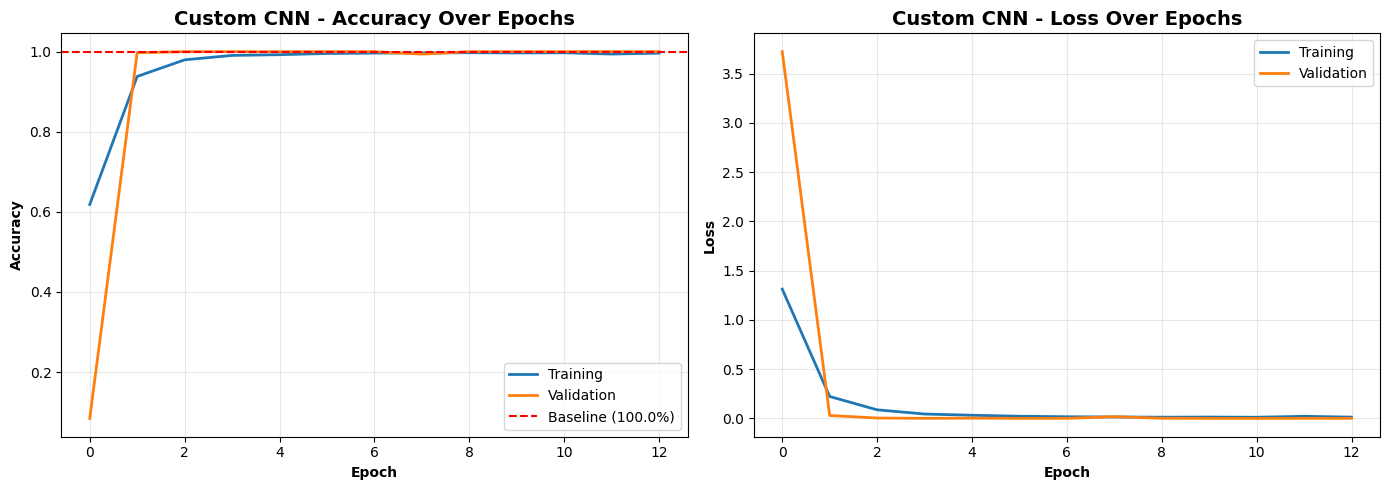

In [13]:
#visualize training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#plot accuracy
ax1.plot(history.history['accuracy'], label='Training', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
ax1.axhline(y=baseline_acc, color='r', linestyle='--', label=f'Baseline ({baseline_acc*100:.1f}%)')
ax1.set_title('Custom CNN - Accuracy Over Epochs', fontweight='bold', fontsize=14)
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

#plot loss
ax2.plot(history.history['loss'], label='Training', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2)
ax2.set_title('Custom CNN - Loss Over Epochs', fontweight='bold', fontsize=14)
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('Loss', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/custom_cnn_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

### results 
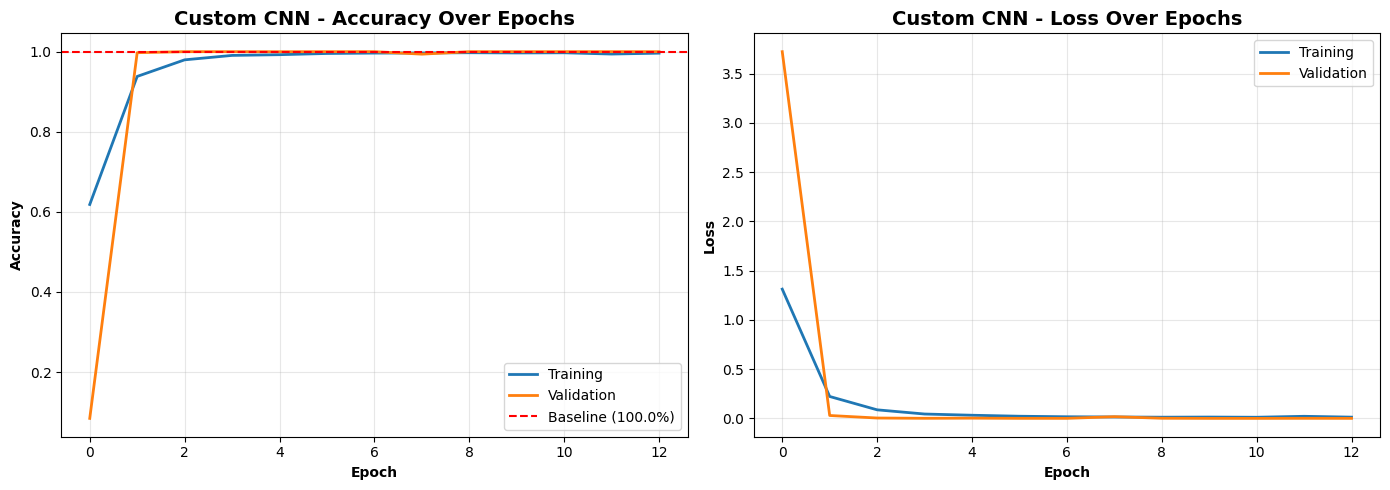

evaluate custom model, get predictions, calcualte metrics , comapre to baseline 

In [17]:
#evaluate
val_loss, val_accuracy = custom_model.evaluate(X_val, y_val, verbose=0)

print(f"\nvalidation perfromance:")
print(f"Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Loss: {val_loss:.4f}")

#get predictions
y_pred = custom_model.predict(X_val, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

#calculate metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')

print(f"\nDeatiled metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f" F1-Score: {f1:.4f}")

#compare to baseline
improvement = (val_accuracy - baseline_acc) * 100
print(f"\nImprovement over baseline:")
print(f"Baseline: {baseline_acc*100:.2f}%")
print(f"Custom CNN: {val_accuracy*100:.2f}%")
print(f"Improvement: +{improvement:.2f} percentage points")


validation perfromance:
Accuracy: 1.0000 (100.00%)
Loss: 0.0038

Deatiled metrics:
Precision: 1.0000
Recall: 1.0000
 F1-Score: 1.0000

Improvement over baseline:
Baseline: 100.00%
Custom CNN: 100.00%
Improvement: +0.00 percentage points


create consusion matrix 

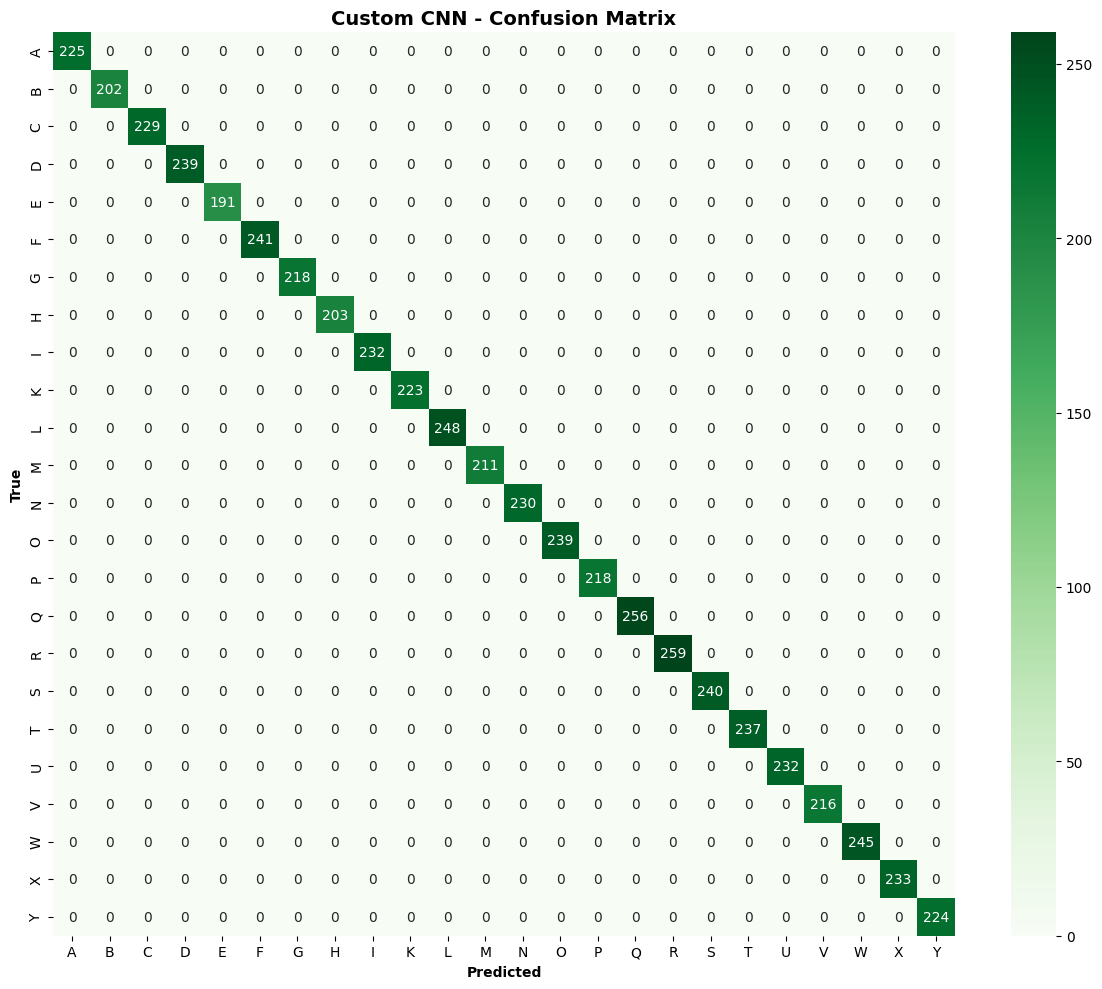

In [18]:
#confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(12, 10))
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 
           'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R',
           'S', 'T', 'U', 'V', 'W', 'X', 'Y']

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=letters, yticklabels=letters)
plt.title('Custom CNN - Confusion Matrix', fontweight='bold', fontsize=14)
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('True', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/custom_cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

pre class accuracy and comparison 

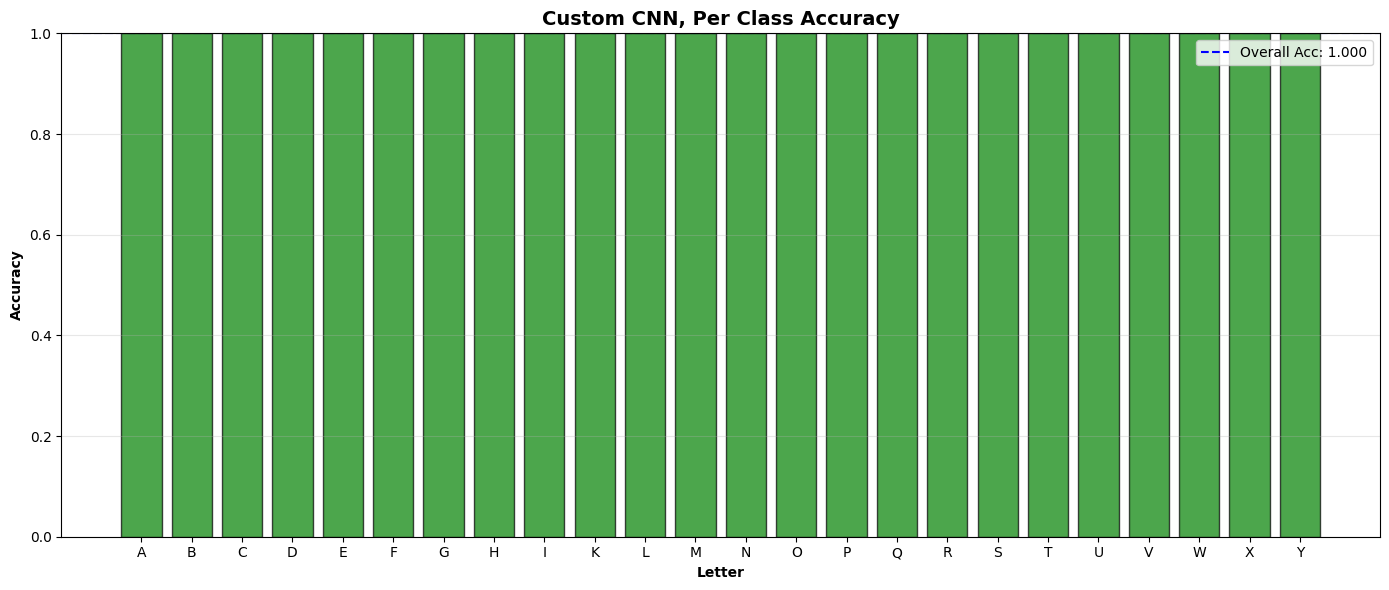


Letters needing improvement:
   A: 1.000
   B: 1.000
   C: 1.000
   D: 1.000
   E: 1.000


In [25]:
#per class accuracy, using actual label values to avoid J gap
label_values = sorted(np.unique(y_true_classes))  # no 9

per_class_acc = []
for i in label_values:
    mask = (y_true_classes == i)
    acc = (y_pred_classes[mask] == i).sum() / mask.sum()
    per_class_acc.append(float(acc))

#plot
plt.figure(figsize=(14, 6))
bars = plt.bar(range(24), per_class_acc, color='green', edgecolor='black', alpha=0.7)
plt.xlabel('Letter', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('Custom CNN, Per Class Accuracy', fontweight='bold', fontsize=14)
plt.xticks(range(24), letters)
plt.ylim(0, 1)
plt.axhline(y=val_accuracy, color='blue', linestyle='--', label=f'Overall Acc: {val_accuracy:.3f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/custom_cnn_per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

#worst performers
worst = sorted(zip(letters, per_class_acc), key=lambda x: x[1])[:5]
print("\nLetters needing improvement:")
for letter, acc in worst:
    print(f"   {letter}: {acc:.3f}")

model comparison chart 

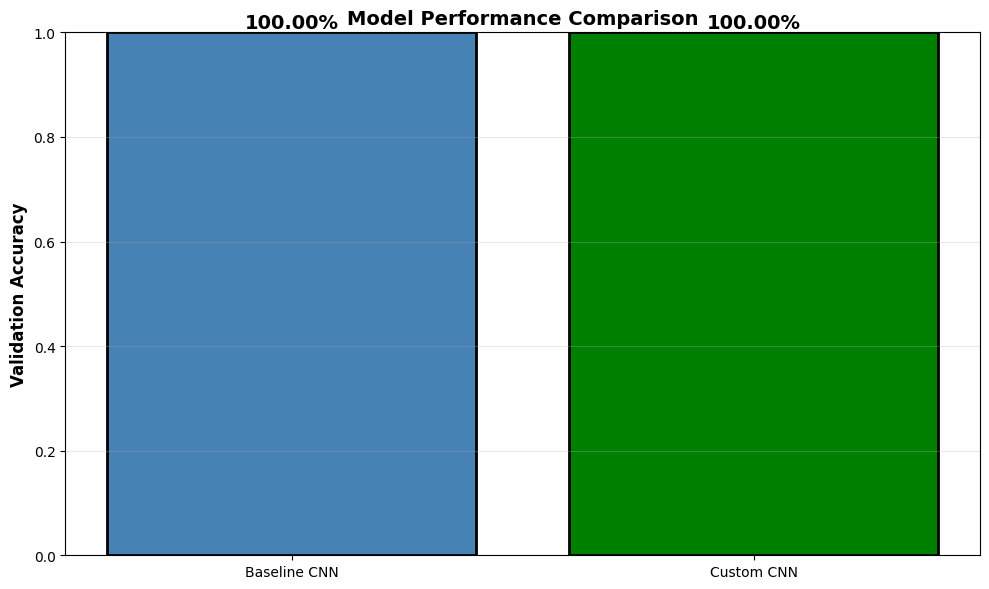


comparison summary:
Baseline CNN: 100.00%
Custom CNN: 100.00%
Improvement: +0.00 percentage points


In [26]:
#create comparison data
models = ['Baseline CNN', 'Custom CNN']
accuracies = [baseline_acc, val_accuracy]

#plot comparison
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, accuracies, color=['steelblue', 'green'], edgecolor='black', linewidth=2)

#add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height*100:.2f}%',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Validation Accuracy', fontweight='bold', fontsize=12)
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\ncomparison summary:")
print(f"Baseline CNN: {baseline_acc*100:.2f}%")
print(f"Custom CNN: {val_accuracy*100:.2f}%")
print(f"Improvement: +{(val_accuracy - baseline_acc)*100:.2f} percentage points")

save metrics

In [24]:
#save custom CNN metrics
metrics_text = f"""
custom cnn model perfromance metrics 

model arhitecture :
- Type: Custom Deep CNN
- Layers: 5 Conv2D, 3 MaxPooling, 1 Dense + Batch Norm + Dropout
- Total Parameters: {total_params:,}

training details:
- Training samples: {X_train.shape[0]:,}
- Validation samples: {X_val.shape[0]:,}
- Epochs trained: {len(history.history['accuracy'])}
- Training time: {training_time:.1f}s ({training_time/60:.1f} min)
- Batch size: 64
- Learning rate: 0.001 (with reduction on plateau)

validation performance:
- Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)
- Precision: {precision:.4f}
- Recall: {recall:.4f}
- F1-Score: {f1:.4f}
- Loss: {val_loss:.4f}

comparison to baseline:
- Baseline accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)
- Custom CNN accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)
- Improvement: +{(val_accuracy - baseline_acc)*100:.2f} percentage points

best epoch:
- Best validation accuracy: {max(history.history['val_accuracy']):.4f}

files saved:
- Model: results/models/custom_cnn_model.h5
- Metrics: results/metrics/custom_cnn_metrics.txt
- Figures: results/figures/custom_cnn_*.png

"""

with open('../results/metrics/custom_cnn_metrics.txt', 'w') as f:
    f.write(metrics_text)

print("\nMetrics saved to: results/metrics/custom_cnn_metrics.txt")
print(metrics_text)


Metrics saved to: results/metrics/custom_cnn_metrics.txt

custom cnn model perfromance metrics 

model arhitecture :
- Type: Custom Deep CNN
- Layers: 5 Conv2D, 3 MaxPooling, 1 Dense + Batch Norm + Dropout
- Total Parameters: 291,449

training details:
- Training samples: 21,964
- Validation samples: 5,491
- Epochs trained: 13
- Training time: 305.5s (5.1 min)
- Batch size: 64
- Learning rate: 0.001 (with reduction on plateau)

validation performance:
- Accuracy: 1.0000 (100.00%)
- Precision: 1.0000
- Recall: 1.0000
- F1-Score: 1.0000
- Loss: 0.0038

comparison to baseline:
- Baseline accuracy: 1.0000 (100.00%)
- Custom CNN accuracy: 1.0000 (100.00%)
- Improvement: +0.00 percentage points

best epoch:
- Best validation accuracy: 1.0000

files saved:
- Model: results/models/custom_cnn_model.h5
- Metrics: results/metrics/custom_cnn_metrics.txt
- Figures: results/figures/custom_cnn_*.png




summary 